# Models and Dynamics

brainmass ships a library of neural-mass models, from simple phenomenological oscillators to
biophysical mean-field models. This tutorial gives you a **map of the families** and the two
tools you need to understand any of them:

- the **phase portrait** — the trajectory in state space, and
- the **bifurcation** — how changing one parameter qualitatively changes the behaviour.

By the end you will be able to orient yourself with {func}`brainmass.list_models`, recognise
the main model families, and read a bifurcation diagram.

:::{note}
This is a guided *tour*, not the full catalogue. For a runnable demo of **every** model — and
help choosing one — see the {doc}`/gallery/index` and {doc}`/howto/choose_a_model`.
:::

In [1]:
import brainmass
import braintools
import brainstate
import brainunit as u
import numpy as np
import matplotlib.pyplot as plt

brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Orient yourself with `list_models()`

{func}`brainmass.list_models` returns a typed catalogue of every public model: its name, its
**category**, how many state variables it integrates, and a one-line use case. It is the
fastest way to see what is available.

In [2]:
print(brainmass.list_models.to_table())

name                     category          #states  use_case                                 
-----------------------  ----------------  -------  -----------------------------------------
HopfStep                 phenomenological  2        Oscillation onset, rhythm generation     
VanDerPolStep            phenomenological  2        Nonlinear relaxation oscillations        
StuartLandauStep         phenomenological  2        Amplitude-controlled oscillations        
FitzHughNagumoStep       phenomenological  2        Excitability, spike generation           
ThresholdLinearStep      phenomenological  2        Fast linear E-I responses                
Generic2dOscillatorStep  phenomenological  2        Flexible planar dynamics (TVB)           
LorenzStep               phenomenological  3        Chaos, coupling test fixture             
LinearStep               phenomenological  1        Baseline node, coupling sanity checks    
WilsonCowanStep          physiological     2        E-I popu

The catalogue groups models into three families:

| Category | What it is | Examples |
|---|---|---|
| **phenomenological** | Minimal models capturing a *behaviour* (oscillation, excitability) without biophysical detail | {class}`~brainmass.HopfStep`, {class}`~brainmass.StuartLandauStep`, {class}`~brainmass.FitzHughNagumoStep` |
| **physiological** | Population firing-rate / mean-field models with interpretable biology | {class}`~brainmass.WilsonCowanStep`, {class}`~brainmass.MontbrioPazoRoxinStep`, {class}`~brainmass.JansenRitStep` |
| **network** | Models that are intrinsically a network of units | {class}`~brainmass.KuramotoNetwork`, the HORN family |

We will visit one model from each of the first two families and a fourth next-generation
mean-field model, and watch a parameter move each one between regimes.

## An oscillator: the Hopf model

The {class}`~brainmass.HopfStep` is the normal form of an oscillation **onset**. Its
bifurcation parameter `a` controls everything: for `a < 0` the origin is a stable focus (any
perturbation decays to rest), while for `a > 0` a **limit cycle** appears whose amplitude
grows like `sqrt(a)`. The transition at `a = 0` is a *supercritical Hopf bifurcation*.

We run the model across a range of `a` and record the peak-to-peak amplitude of the settled
trajectory — this traces the bifurcation diagram directly.

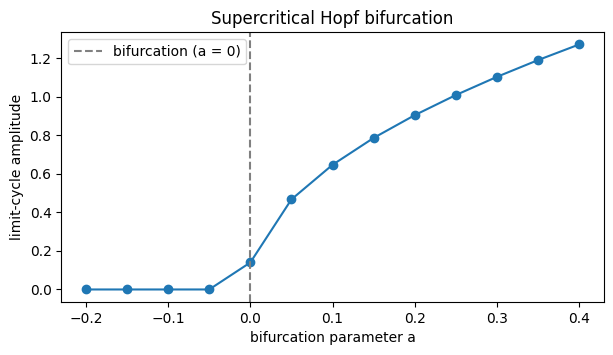

In [3]:
def limit_cycle_amplitude(a):
    """Peak-to-peak amplitude of the settled Hopf trajectory for bifurcation param a."""
    node = brainmass.HopfStep(
        in_size=1, a=a, w=0.3, init_x=braintools.init.Constant(0.1)
    )
    r = brainmass.Simulator(node, dt=0.1 * u.ms).run(
        400.0 * u.ms, monitors=["x"], transient=200.0 * u.ms
    )
    x = np.asarray(r["x"][:, 0])
    return x.max() - x.min()

a_values = np.linspace(-0.2, 0.4, 13)
amplitudes = [limit_cycle_amplitude(a) for a in a_values]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(a_values, amplitudes, "o-")
ax.axvline(0.0, color="grey", ls="--", label="bifurcation (a = 0)")
ax.set_xlabel("bifurcation parameter a")
ax.set_ylabel("limit-cycle amplitude")
ax.set_title("Supercritical Hopf bifurcation")
ax.legend();

The amplitude is flat at zero while `a < 0` (the unit is silent), then rises smoothly once
`a` crosses zero. A single number turned a quiet node into a sustained oscillator — that is a
bifurcation, and it is the reason these models are useful for studying rhythm generation.

## An excitable unit: FitzHugh–Nagumo phase portrait

The {class}`~brainmass.FitzHughNagumoStep` we met in tutorial 01 has two variables, so its
dynamics live in a 2-D **phase plane** `(V, w)`. Driven steadily it settles onto a closed
loop — the limit cycle — which {func}`brainmass.viz.plot_phase_portrait` draws by plotting
one variable against the other.

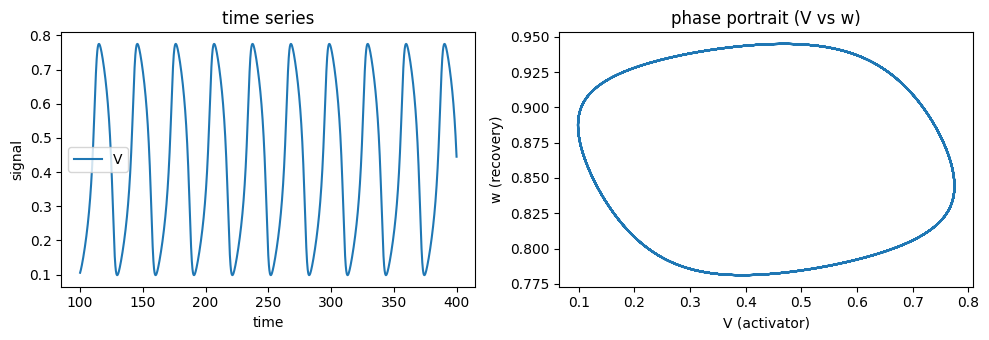

In [4]:
fhn = brainmass.FitzHughNagumoStep(in_size=1)
r = brainmass.Simulator(fhn, dt=0.1 * u.ms).run(
    400.0 * u.ms,
    inputs=lambda i, t: (1.0,),   # steady drive -> sustained spiking
    monitors=["V", "w"],
    transient=100.0 * u.ms,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
brainmass.viz.plot_timeseries(r["V"], ts=r["ts"], labels=["V"], ax=ax1)
ax1.set_title("time series")
brainmass.viz.plot_phase_portrait(r["V"][:, 0], r["w"][:, 0], ax=ax2)
ax2.set_xlabel("V (activator)")
ax2.set_ylabel("w (recovery)")
ax2.set_title("phase portrait (V vs w)")
fig.tight_layout()

## An E–I rate model: Wilson–Cowan

The {class}`~brainmass.WilsonCowanStep` is a *physiological* model: two coupled populations,
excitatory (`rE`) and inhibitory (`rI`) firing rates, with interpretable connection weights.
Depending on its parameters it can rest at a fixed point or oscillate. Here we run it from a
small perturbation and watch the two populations relax together.

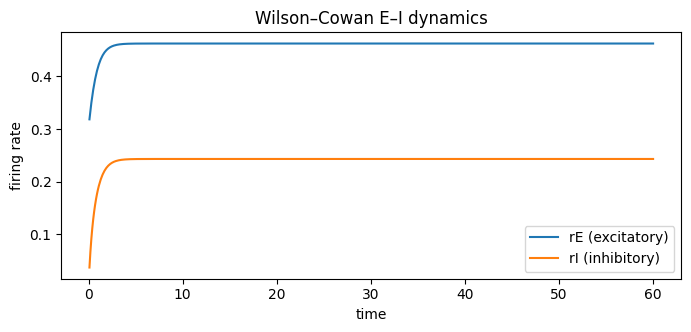

In [5]:
wc = brainmass.WilsonCowanStep(
    in_size=1, rE_init=braintools.init.Constant(0.3)
)
r = brainmass.Simulator(wc, dt=0.1 * u.ms).run(60.0 * u.ms, monitors=["rE", "rI"])

fig, ax = plt.subplots(figsize=(8, 3.2))
brainmass.viz.plot_timeseries(r["rE"], ts=r["ts"], labels=["rE (excitatory)"], ax=ax)
brainmass.viz.plot_timeseries(r["rI"], ts=r["ts"], labels=["rI (inhibitory)"], ax=ax)
ax.set_title("Wilson–Cowan E–I dynamics")
ax.set_ylabel("firing rate");

## A next-generation mean-field: Montbrió–Pazó–Roxin

The {class}`~brainmass.MontbrioPazoRoxinStep` is an *exact* mean-field reduction of a network
of quadratic integrate-and-fire neurons. Its state is the population firing rate `r` (a
unit-aware quantity in `Hz`) and the mean membrane potential `v`. The coupling strength `J`
moves it between a low-rate fixed point and self-sustained oscillations.

We compare two coupling strengths and plot the firing rate over time.

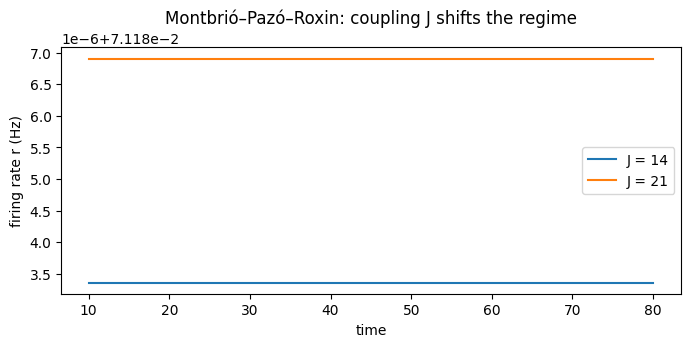

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.2))

for J in [14.0, 21.0]:
    mpr = brainmass.MontbrioPazoRoxinStep(in_size=1, J=J, eta=-5.0)
    r = brainmass.Simulator(mpr, dt=0.1 * u.ms).run(
        80.0 * u.ms, monitors=["r"], transient=10.0 * u.ms
    )
    # r['r'] is unit-aware (Hz); viz strips the unit for plotting.
    brainmass.viz.plot_timeseries(r["r"], ts=r["ts"], labels=[f"J = {J:.0f}"], ax=ax)

ax.set_title("Montbrió–Pazó–Roxin: coupling J shifts the regime")
ax.set_ylabel("firing rate r (Hz)");

## What you learned

- {func}`brainmass.list_models` (and `.to_table()`) is your map of the model families:
  **phenomenological**, **physiological**, and **network**.
- A **phase portrait** ({func}`~brainmass.viz.plot_phase_portrait`) shows the trajectory in
  state space; for a 2-D model a limit cycle is a closed loop.
- A **bifurcation** is a qualitative change of behaviour as a parameter crosses a threshold —
  the Hopf `a`, the MPR coupling `J`.
- The same `Simulator`-driven workflow applies to every model, so swapping models is cheap.

## Next steps

- {doc}`/tutorials/03_noise` — real activity fluctuates; add stochastic dynamics.
- {doc}`/howto/choose_a_model` — pick the right model for your question.
- {doc}`/gallery/index` — the full model zoo, one runnable demo each.